# BASELINES DEL MODEL

## Imports necessaris

In [42]:
import os
import joblib
import warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.base import BaseEstimator, ClassifierMixin

import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, 
    precision_recall_fscore_support, 
    precision_recall_curve, 
    auc,
    fbeta_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")

### Definicions inicials

In [43]:
DATA_PATH = "../data/processed/dataset_final_pcc.csv"
RANDOM_STATE = 42

print("--- Iniciant obtenció de resultats del BASELINE ---")

if not os.path.exists(DATA_PATH):
    print(f"ERROR: No trobo {DATA_PATH}")
    exit()

df = pd.read_csv(DATA_PATH)

--- Iniciant obtenció de resultats del BASELINE ---


## Preprocessament Comú

In [44]:
from joblib import numpy_pickle_utils
drop_cols = ["id_pacient", "target", "cronic"]
X_all = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()

# Separem les columnes per a processar-les diferent
num_cols = X_all.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_all.select_dtypes(include=["object", "category"]).columns.tolist()

# Preprocessador per tractar les columnes numèriques i categòriques
preprocessor = ColumnTransformer(
    transformers=[
        # Imputem la mediana i escalem les columnes numèriques (mitjana=0, desviació típica=1)
        ("num", Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_cols),
        # Imputem la moda i convertim les columnes categòriques en one-hot
        ("cat", Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
    ]
)


## Mean Baseline

In [45]:
class MeanBaseline(ClassifierMixin, BaseEstimator):
    def __init__(self):
        self.mean_value = None

    def fit(self, X, y):
        # L'entrenament és calcular la mitjana
        self.mean_value = np.mean(y)
        
        # Crea com a mínim un atribut que acabi en '_'
        self.classes_ = np.unique(y)   # Molt recomanable per a classificadors
        self.is_fitted_ = True         # Marca genèrica per a sklearn
        
        return self

    def predict(self, X):
        """Predecir: siempre devolver la media"""
        return np.full(len(X), self.mean_value)

## Validació Encreuada (Cross-Validation)

A continuació implementem una validació encreuada de 5 folds (`StratifiedKFold`) per obtenir mètriques d'avaluació més robustes i generals (Out-Of-Fold) sobre tot el dataset.

### Definicions

In [49]:
# Definim el target jeràrquic global per a la validació encreuada
# 0: NO crònic, 1: PCC, 2: MACA
y_target = df["target"].values

target_names = ["NO", "PCC", "MACA"]

# Preparem la validació encreuada 
CV_KFold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Matrius per desar les prediccions i probabilitats out-of-fold (OOF)
oof_preds = np.zeros(len(df))
oof_probs = np.zeros((len(df), len(target_names)))

# Guardem el model a utilitzar en una CONSTANT
MODEL1 = MeanBaseline()
MODEL2 = MeanBaseline()


### Cross-Validation

In [52]:
print(f"--- Iniciant Cross-Validation ({CV_KFold.n_splits} folds) ---")

for fold, (train_idx, val_idx) in enumerate(CV_KFold.split(X_all, y_target)):
    print(f"Entrenant Fold {fold + 1}/{CV_KFold.n_splits}...")
    
    # Obtenim les files d'entrenament i les de validació
    X_train_fold, X_val_fold = X_all.iloc[train_idx], X_all.iloc[val_idx]

    # Obtenim el el valor a predir de l'entrenament
    y_train_fold = y_target[train_idx]
    

    # --- 
    # Entrenament 
    # ---
    # --- ESTAT 1: Crònic (1) vs NO (0) ---
    y1_train_fold = (y_train_fold > 0).astype(int)
    model1_fold = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", MODEL1)
    ])
    model1_fold.fit(X_train_fold, y1_train_fold)
    

    # --- ESTAT 2: PCC (1) vs MACA (2) ---

    # Primer escollim les files que sí que son croniques
    chronic_train_mask = y_train_fold > 0
    X2_train_fold = X_train_fold[chronic_train_mask]
    y2_train_fold = y_train_fold[chronic_train_mask]
    
    model2_fold = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", MODEL2)
    ])
    model2_fold.fit(X2_train_fold, y2_train_fold)
    

    # --- 
    # Predicció del Fold de Validació 
    # ---
    # Probabilitat de ser crònic
    y1_prob = model1_fold.predict(X_val_fold)
    print (y1_prob)

    y1_pred = (y1_prob >= 0.70).astype(int)
    
    # Predicció dels PCC o MACA entre els crònics
    y_pred = np.zeros_like(y1_pred)
    chronic_indices = np.where(y1_pred == 1)[0]
    
    if len(chronic_indices) > 0:
        X_chronic = X_val_fold.iloc[chronic_indices]

        y2_probs = model2_fold.predict(X_chronic)
        
        # Gestió robusta per a sortides 1D (MeanBaseline) i 2D (classificadors reals)
        if y2_probs.ndim > 1:
            p_maca_detected = y2_probs[:, 1]
        else:
            mean_val = y2_probs[0]
            prob_maca = mean_val - 1 if mean_val > 1 else mean_val
            p_maca_detected = np.full(len(y2_probs), prob_maca)
            
        THRESHOLD_MACA = 0.40
        y2_pred = np.where(p_maca_detected >= THRESHOLD_MACA, 2, 1)
        y_pred[chronic_indices] = y2_pred
        
    oof_preds[val_idx] = y_pred


    print (y_pred)
    
    # Càlcul de probabilitats globals out-of-fold per a PR-AUC i Brier Score
    p_no = 1 - y1_prob
    p_chronic = y1_prob
    
    y2_probs_all = model2_fold.predict(X_val_fold)

    if y2_probs_all.ndim > 1:
        p_pcc_s2 = y2_probs_all[:, 0]
        p_maca_s2 = y2_probs_all[:, 1]
    else:
        mean_val = y2_probs_all[0]
        prob_maca = mean_val - 1 if mean_val > 1 else mean_val
        p_maca_s2 = np.full(len(y2_probs_all), prob_maca)
        p_pcc_s2 = np.full(len(y2_probs_all), 1.0 - prob_maca)
        
    p_pcc_val = p_chronic * p_pcc_s2
    p_maca_val = p_chronic * p_maca_s2
    
    oof_probs[val_idx] = np.column_stack([p_no, p_pcc_val, p_maca_val])

print("--- Cross-Validation finalitzada! ---")


--- Iniciant Cross-Validation (5 folds) ---
Entrenant Fold 1/5...
[0.22627882 0.22627882 0.22627882 ... 0.22627882 0.22627882 0.22627882]
[0 0 0 ... 0 0 0]
Entrenant Fold 2/5...
[0.22627882 0.22627882 0.22627882 ... 0.22627882 0.22627882 0.22627882]
[0 0 0 ... 0 0 0]
Entrenant Fold 3/5...
[0.22630433 0.22630433 0.22630433 ... 0.22630433 0.22630433 0.22630433]
[0 0 0 ... 0 0 0]
Entrenant Fold 4/5...
[0.22630433 0.22630433 0.22630433 ... 0.22630433 0.22630433 0.22630433]
[0 0 0 ... 0 0 0]
Entrenant Fold 5/5...
[0.22630433 0.22630433 0.22630433 ... 0.22630433 0.22630433 0.22630433]
[0 0 0 ... 0 0 0]
--- Cross-Validation finalitzada! ---


### Avaluació de les prediccions


AVALUACIÓ (CROSS-VALIDATION)

----------------------------------------
1. MÈTRIQUES DETALLADES (CV):
----------------------------------------
        Precisió  Recall  F1-Score  F2-Score  PR-AUC  \
Classe                                                 
NO        0.7737     1.0    0.8724    0.9447  0.8189   
PCC       0.0000     0.0    0.0000    0.0000  0.4326   
MACA      0.0000     0.0    0.0000    0.0000  0.2293   

        Brier Score (Calibratge)  Suport  
Classe                                    
NO                        0.1751   29325  
PCC                       0.1537    7187  
MACA                      0.0353    1390  

----------------------------------------
2. MITJANES GENERALS (MACRO AVG - CV):
----------------------------------------
Macro avg Precision: 0.2579
Macro avg Recall   : 0.3333
Macro avg F1-Score : 0.2908
Macro avg F2-Score : 0.3149

----------------------------------------
3. MATRIU DE CONFUSIÓ (ABSOLUTA - CV):
----------------------------------------
     

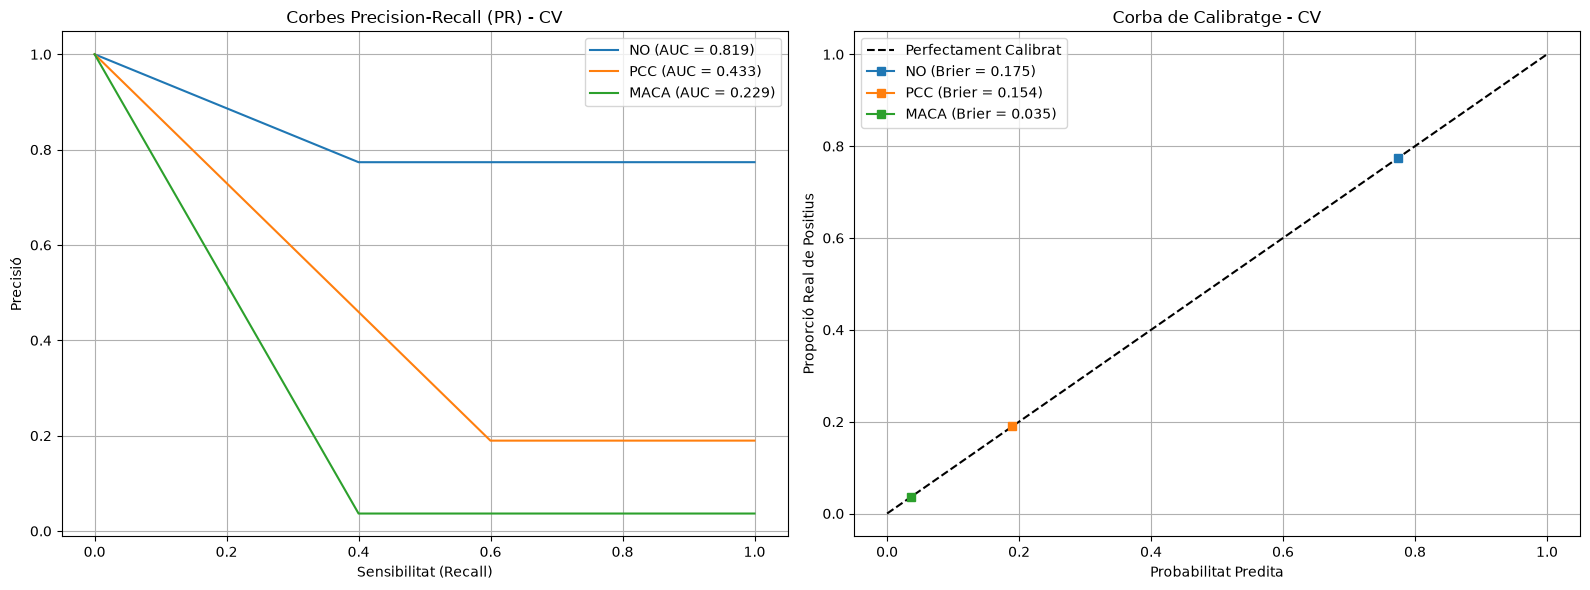

In [53]:
print("\n" + "="*50)
print("AVALUACIÓ (CROSS-VALIDATION)")
print("="*50)

y_final_true_bin = pd.get_dummies(y_target).reindex(columns=[0, 1, 2], fill_value=0).values

# Càlculs bàsics (Precision, Recall, F1)
prec, rec, f1, support = precision_recall_fscore_support(y_target, oof_preds, average=None)

# Càlcul de l'F2-Score per a cada classe (dóna el doble d'importància al Recall)
f2_scores = fbeta_score(y_target, oof_preds, beta=2, average=None)

# PR-AUC i Brier Score per a cada classe
pr_aucs = []
brier_scores = []
for i in range(len(target_names)):
    precision_curve, recall_curve, _ = precision_recall_curve(y_final_true_bin[:, i], oof_probs[:, i])
    pr_aucs.append(auc(recall_curve, precision_curve))
    brier_scores.append(brier_score_loss(y_final_true_bin[:, i], oof_probs[:, i]))

# 1. REPORTE GENERAL I TAULA DE MÈTRIQUES PER CLASSE
print("\n" + "-"*40)
print("1. MÈTRIQUES DETALLADES (CV):")
print("-"*40)
metrics_data = {
    "Classe": target_names,
    "Precisió": prec,
    "Recall": rec,
    "F1-Score": f1,
    "F2-Score": f2_scores,
    "PR-AUC": pr_aucs,
    "Brier Score (Calibratge)": brier_scores,
    "Suport": support
}
df_metrics = pd.DataFrame(metrics_data).set_index("Classe")
print(df_metrics.round(4))

# 2. MITJANES GENERALS (AVGS)
print("\n" + "-"*40)
print("2. MITJANES GENERALS (MACRO AVG - CV):")
print("-"*40)
macro_f2 = fbeta_score(y_target, oof_preds, beta=2, average='macro')
print(f"Macro avg Precision: {np.mean(prec):.4f}")
print(f"Macro avg Recall   : {np.mean(rec):.4f}")
print(f"Macro avg F1-Score : {np.mean(f1):.4f}")
print(f"Macro avg F2-Score : {macro_f2:.4f}")

# 3. MATRIUS DE CONFUSIÓ (ABSOLUTA I NORMALITZADA)
cm = confusion_matrix(y_target, oof_preds)
df_cm = pd.DataFrame(cm, index=target_names, columns=["Pred_NO", "Pred_PCC", "Pred_MACA"])
print("\n" + "-"*40)
print("3. MATRIU DE CONFUSIÓ (ABSOLUTA - CV):")
print("-"*40)
print(df_cm)

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
df_cm_norm = pd.DataFrame(cm_norm, index=target_names, columns=["Pred_NO", "Pred_PCC", "Pred_MACA"])
print("\n" + "-"*40)
print("4. MATRIU DE CONFUSIÓ NORMALITZADA (CV):")
print("-"*40)
print((df_cm_norm * 100).round(2).astype(str) + " %")

# 4. VISUALITZACIONS (CORBES PR I CALIBRATGE)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# A. Gràfic de les Corbes Precision-Recall (PR)
ax_pr = axes[0]
for i, name in enumerate(target_names):
    precision_curve, recall_curve, _ = precision_recall_curve(y_final_true_bin[:, i], oof_probs[:, i])
    ax_pr.plot(recall_curve, precision_curve, label=f"{name} (AUC = {pr_aucs[i]:.3f})")
ax_pr.set_title("Corbes Precision-Recall (PR) - CV")
ax_pr.set_xlabel("Sensibilitat (Recall)")
ax_pr.set_ylabel("Precisió")
ax_pr.legend()
ax_pr.grid(True)

# B. Gràfic de la Corba de Calibratge (Calibration Curve)
ax_cal = axes[1]
ax_cal.plot([0, 1], [0, 1], "k--", label="Perfectament Calibrat")
for i, name in enumerate(target_names):
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_final_true_bin[:, i], oof_probs[:, i], n_bins=10, strategy='uniform'
    )
    ax_cal.plot(mean_predicted_value, fraction_of_positives, "s-", label=f"{name} (Brier = {brier_scores[i]:.3f})")
ax_cal.set_title("Corba de Calibratge - CV")
ax_cal.set_xlabel("Probabilitat Predita")
ax_cal.set_ylabel("Proporció Real de Positius")
ax_cal.legend()
ax_cal.grid(True)

plt.tight_layout()
plt.show()